In [1]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
from utilities import find_best_grid_point, get_station_coords

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

In [4]:
## Read all data
%autoreload 2
from analyses_level2.read_data import AvailableData, create_data_reader

# File path
data_path = "../data/"

# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


In [5]:
ds_all

<xarray.Dataset>
Dimensions:             (time: 114106, dataset: 7)
Coordinates:
  * time                (time) datetime64[ns] 2002-05-31T23:00:00 ... 2023-12...
  * dataset             (dataset) <U9 'CO2' 'CO2_flask' ... 'CH4_flask' 'O3'
Data variables: (12/17)
    site_gaw_id         (dataset, time) object nan nan nan nan ... nan nan nan
    value               (dataset, time) float64 nan nan nan ... 32.78 36.53
    value_unc           (dataset, time) float64 nan nan nan ... 2.32 0.7698
    nvalue              (dataset, time) float64 nan nan nan nan ... nan nan nan
    latitude            (dataset, time) float64 nan nan nan nan ... nan nan nan
    longitude           (dataset, time) float64 nan nan nan nan ... nan nan nan
    ...                  ...
    QCflag              (dataset, time) float64 nan nan nan nan ... 0.0 0.0 0.0
    instrument          (dataset, time) float64 nan nan nan nan ... nan nan nan
    measurement_method  (dataset, time) float64 nan nan nan nan ... nan nan nan
    scale               (dataset, time) float64 nan nan nan nan ... nan nan nan
    unit                (dataset) <U3 'ppm' 'ppm' 'ppb' 'ppb' 'ppb' 'ppb' 'ppb'
    species             (dataset) <U3 'CO2' 'CO2' 'CO' 'CO' 'CH4' 'CH4' 'O3'

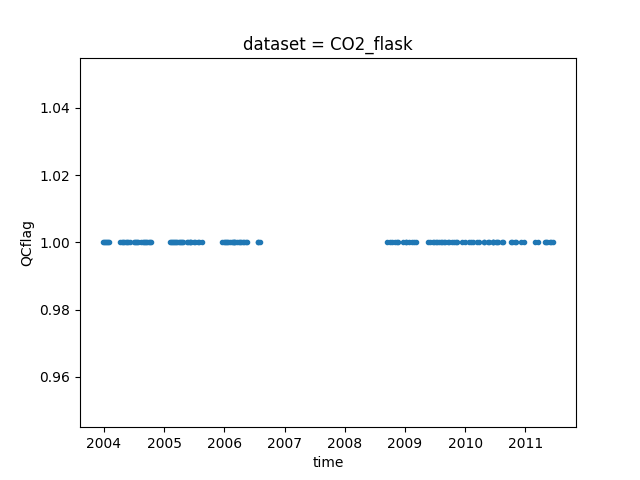

In [6]:
## check flask data
sel_spec = 'CO2_flask'

plt.figure()
ds = ds_all.sel(dataset=sel_spec)
ds = ds.where(~np.isnan(ds.value), drop=True) # remove times where we have no data
ds.QCflag.plot(ls='',marker='.')
plt.show()


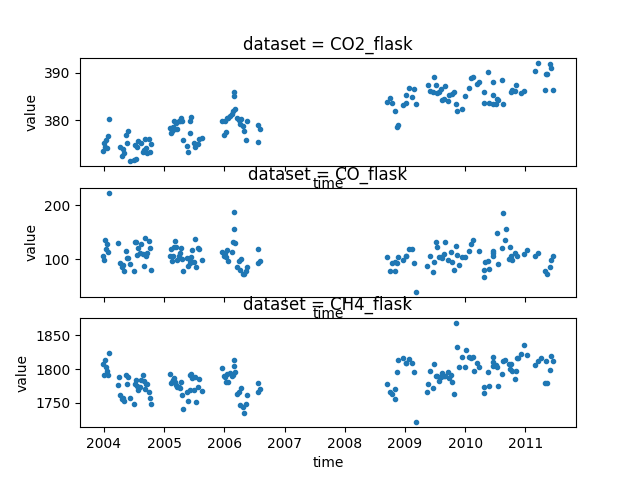

In [7]:
#select all flask species and plot flags: (set 'FLASK_FLAG_CORR' : False)
sel_species = [s for s in selected_data if 'flask' in s]

fig, axs = plt.subplots(len(sel_species),1,sharex=True)
for s,ax in zip(sel_species,axs):
    ds = ds_all.sel(dataset=s)
    ds.value.plot(ax=ax,ls='',marker='.')
    
    # check QCflag = 3
    ds.where(ds.QCflag==3).value.plot(ax=ax,ls='',marker='.',c='r')

    #check original flag (reject if first character is not '.' ) -> gives the same!
    #mask_flag = [str(s)[0] != '.' if isinstance(s, str) else False for s in ds.ORG_QCflag.values]
    #mask_dataarray = xr.DataArray(mask_flag, dims='time', coords={'time': ds['time']})
    #if any(mask_flag):
    #    ds.where(mask_dataarray,drop=True).value.plot(ax=ax,ls='',marker='x',c='g')


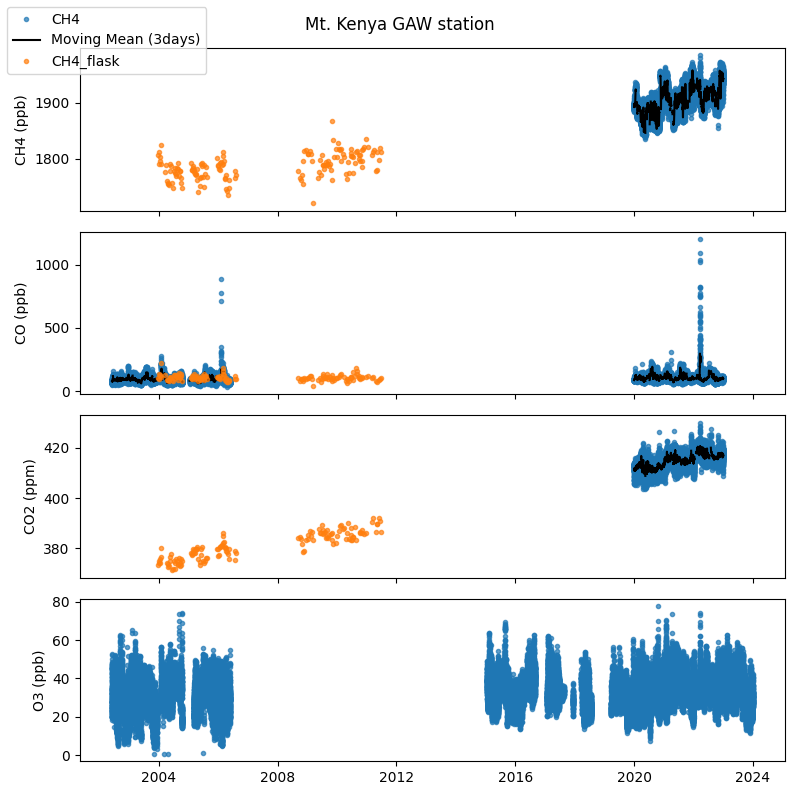

In [8]:
sel_species = ds_all.species 
unique_species = np.unique(sel_species)

#moving window
mw = 24*3 #hours

fig, axs = plt.subplots(len(unique_species),1,sharex=True,figsize=(8,len(unique_species)*2))
for s,ax in zip(unique_species,axs):
    ds_sel = ds_all.where(ds_all.species==s,drop=True)

    #function to plot each subplot
    def plot_data(i_s,mw_temp):
        ds_sel.sel(dataset=i_s).value.plot(ax=ax,ls='',marker='.',alpha=0.7,label=str(i_s))
        #moving mean
        if ii.astype(str).str.contains('flask') == False:
            ds_sel.sel(dataset=i_s).value.rolling(time=mw_temp,center=True,min_periods=mw_temp/2).mean().plot(
            ax=ax,ls='-',c='k',label=f'Moving Mean ({int(mw_temp/24)}days)') #

    if len(ds_sel.dataset)>1: #several datasets with same species
        for ii in ds_sel.dataset:
            # plot data (adapt moving window for flask)
            plot_data(ii.values, mw) #mw*3 if ii.astype(str).str.contains('flask') else mw
    else:
        plot_data(s,mw)
    
    ax.set_ylabel(f'{ds_sel.species.values[0]} ({ds_sel.unit.values[0]})')
    ax.set_xlabel('')
    ax.set_title('')
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper left')
plt.suptitle('Mt. Kenya GAW station')
plt.tight_layout()

    


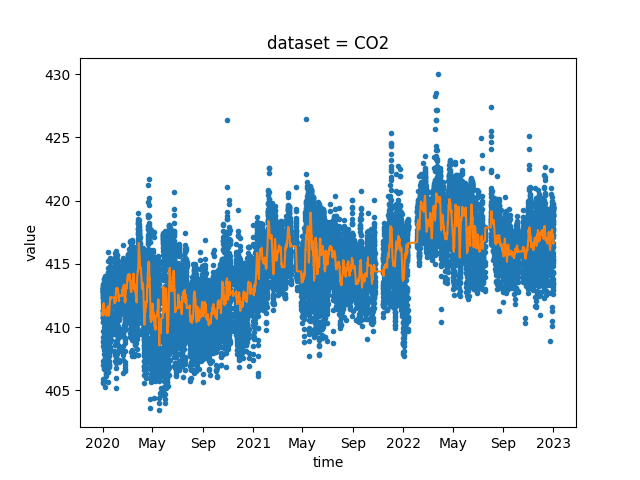

In [7]:
#moving window
mw = 24*3 #hours

plt.figure()
ds = ds_all.sel(dataset='CO2')
ds.value.plot(ls='',marker='.')

ds.value.dropna('time').rolling(time=mw,center=True,min_periods=mw/2).mean().plot(ls='-')

# check QCflag = 3
ds.where(ds.QCflag==3).value.plot(ls='',marker='.',c='r')


plt.show()

### Compare to CAMS

In [57]:

%autoreload 2
import read_cams

## this takes some time (need to do it once, then just load the nc file in the next cell)
#cams_best_grid = read_cams.get_best_cams(ds_all,save_netcdf=True)

take 3h mean of observations
take 6h mean of observations
find best grid for co2_invgg
check corr. for -2.535211267605632, 32.5, 0.0
check corr. for -2.535211267605632, 32.5, 1.0
check corr. for -2.535211267605632, 32.5, 2.0
check corr. for -2.535211267605632, 32.5, 3.0
check corr. for -2.535211267605632, 32.5, 4.0
check corr. for -2.535211267605632, 32.5, 5.0
check corr. for -2.535211267605632, 32.5, 6.0
check corr. for -2.535211267605632, 32.5, 7.0
check corr. for -2.535211267605632, 32.5, 8.0
check corr. for -2.535211267605632, 32.5, 9.0
check corr. for -2.535211267605632, 32.5, 10.0
check corr. for -2.535211267605632, 32.5, 11.0
check corr. for -2.535211267605632, 32.5, 12.0
check corr. for -2.535211267605632, 32.5, 13.0
check corr. for -2.535211267605632, 32.5, 14.0
check corr. for -2.535211267605632, 32.5, 15.0
check corr. for -2.535211267605632, 32.5, 16.0
check corr. for -2.535211267605632, 32.5, 17.0
check corr. for -2.535211267605632, 32.5, 18.0
check corr. for -2.53521126760

In [9]:
cams_best_grid = xr.open_dataset(f"{data_path}/cams/cams_best_grid_MKN_all.nc")

In [10]:
## resample observations
# remove unnecessary variables for simplication
variables_to_keep= ['time','dataset','value','value_unc','unit','species']
ds_all_simple = ds_all.drop_vars(set(ds_all.variables) - set(variables_to_keep))


# Resample only time-dependent variables
time_dependent_variables = [var for var in ds_all_simple.data_vars if 'time' in ds_all_simple[var].dims]
non_time_dependent_variables = [var for var in ds_all_simple.data_vars if var not in time_dependent_variables or not 'time']

ds_all_3h = ds_all_simple[time_dependent_variables].resample(time='3h').mean(keep_attrs=True)
ds_all_6h = ds_all_simple[time_dependent_variables].resample(time='6h').mean(keep_attrs=True)
# add non-time dependent variables again
for var in non_time_dependent_variables:
    ds_all_3h[var] = ds_all_simple[var]
    ds_all_6h[var] = ds_all_simple[var]

In [72]:
###### --- FOR ALL FIGURES --- #####
## Select the time period and species to plot


tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

sel_species = ds_all.species
unique_species = np.unique(sel_species)

species_sel = unique_species

#species_sel = ["CO2", "CO"]

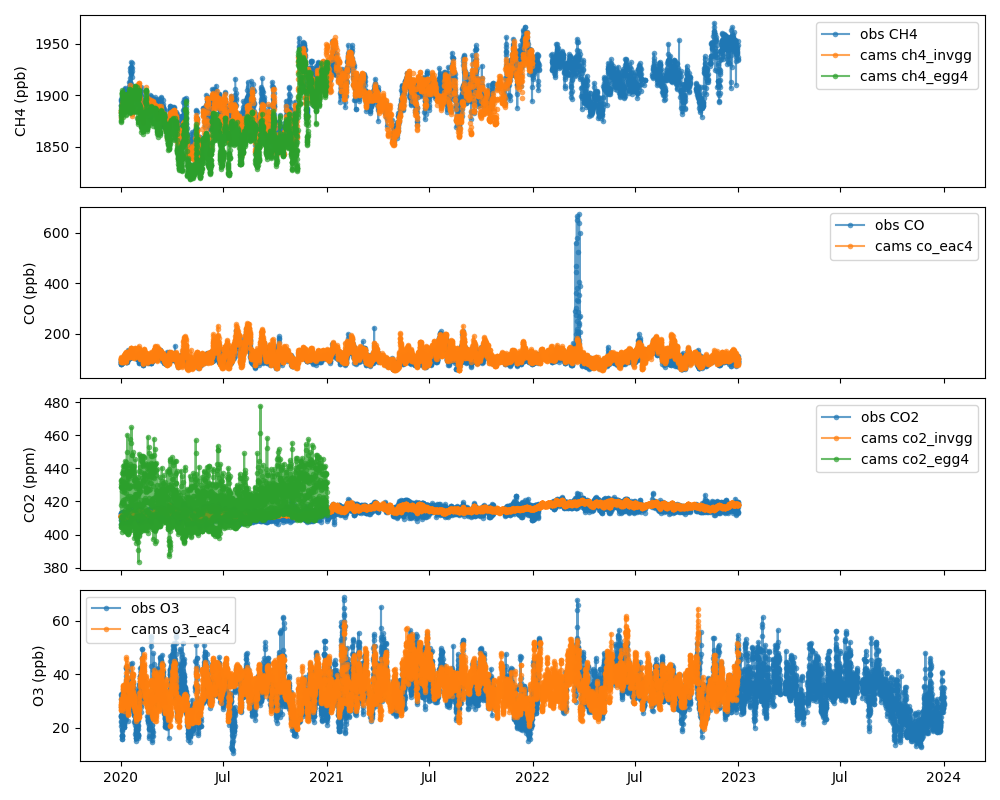

In [73]:
## plot cams versus observations
alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    if s == "CH4":
        ds = ds_all_6h  # ch4 has 6h resolution
    else:
        ds = ds_all_3h

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
    # select cams datasets that exist for this species
    cams_datasets_sel = [cams_sel for cams_sel in cams_best_grid.dataset.values if f"{s.lower()}_" in cams_sel]
    cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

    # function to plot each subplot
    def plot_data(ds,label):
        if 'flask' in str(ds.dataset.values):
            m = '.'
            l = ''
        else:
            m = '.'
            l = '-'
        ds.plot(
            ax=ax,
            ls=l,
            marker=m,
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label} {str(ds.dataset.values)}",
        )

    # plot obs
    if len(ds_sel.dataset) > 1:  # several obs datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
                spec.dataset.values
                for spec in ds_sel.dataset
                if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
            ]
        for ds_i in ds_sel.sel(dataset=variables_to_keep).dataset:
            plot_data(ds_sel.sel(dataset=ds_i.values)["value"], 'obs')
    else:
        plot_data(ds_sel.sel(dataset=s)["value"], 'obs')

    # plot cams
    if len(cams.dataset) > 1:  # several cams datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
                spec.dataset.values
                for spec in cams.dataset
                if cams.sel(dataset=spec)["value"].isnull().all() == False
            ]
        for cams_i in cams.sel(dataset=variables_to_keep).dataset:
            plot_data(cams.sel(dataset=cams_i)["value"], 'cams')
    else:
        plot_data(cams.isel(dataset=0)["value"], 'cams')

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title("")
    ax.legend()
plt.tight_layout()
plt.show()

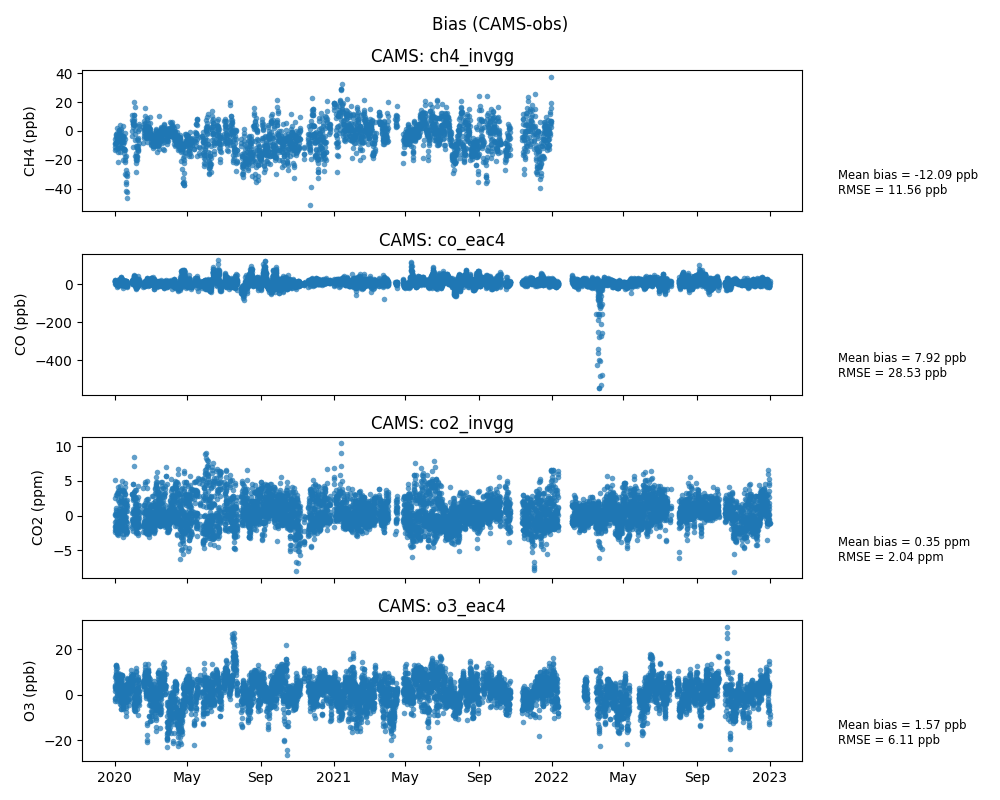

In [69]:
## plot bias between cams and observations
def root_mean_squared_error(x, y):
    return np.sqrt(((x - y) ** 2).mean(dim="time"))


def mean_bias(x, y):
    return (x).mean(dim="time") - (y).mean(dim="time")


alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    # select CAMS for which I want to show the bias
    if s == "CO2":
        cams_dataset = "co2_invgg" #"co2_egg4" 
    elif s == "CH4":
        cams_dataset = "ch4_invgg" #"ch4_egg4"
    elif s == "CO":
        cams_dataset = "co_eac4"
    elif s == "O3":
        cams_dataset = "o3_eac4"

    # select obs, ch4_invgg has 6h resolution
    if cams_dataset == "ch4_invgg": 
        ds = ds_all_6h  # ch4 has 6h resolution
    else:
        ds = ds_all_3h

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)

    # function to plot each subplot
    def plot_bias(x):
        x.plot(
            ax=ax,
            ls="",
            marker=".",
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"cams-obs",
        )

    # plot bias
    cams = cams_best_grid.sel(dataset=cams_dataset, time=slice(tsel1, tsel2))
    if len(ds_sel.dataset) > 1:  # several datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_sel.dataset
            if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for ii in ds_sel.sel(dataset=variables_to_keep).dataset:
            plot_bias(cams["value"] - ds_sel.sel(dataset=ii)["value"])
    else:
        plot_bias(cams["value"] - ds_sel.sel(dataset=s)["value"])

    mbias = mean_bias(cams["value"], ds_sel.sel(dataset=s)["value"]).values
    rmse = root_mean_squared_error(cams["value"], ds_sel.sel(dataset=s)["value"]).values
    ax.text(
        1.05,
        0.2,
        f"Mean bias = {mbias:.2f} {ds_sel.unit[0].values} \nRMSE = {rmse:.2f} {ds_sel.unit[0].values}",
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize='small'
    )


    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title(f"CAMS: {cams_dataset}")
    # ax.legend()
plt.suptitle("Bias (CAMS-obs)")
plt.tight_layout()

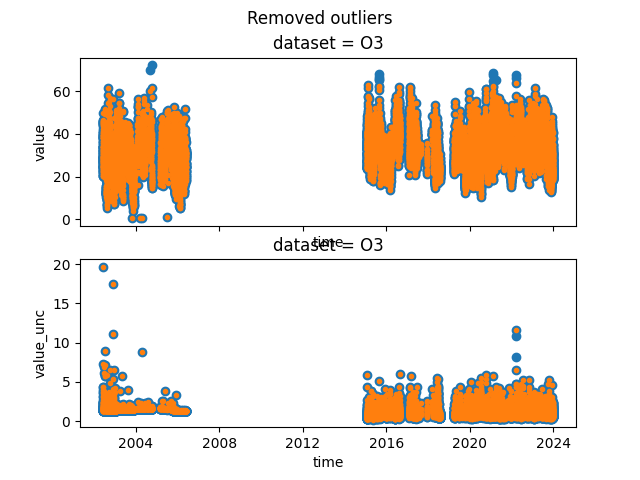

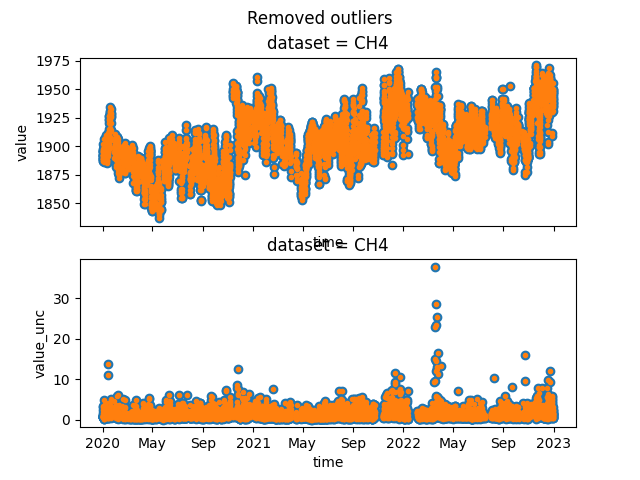

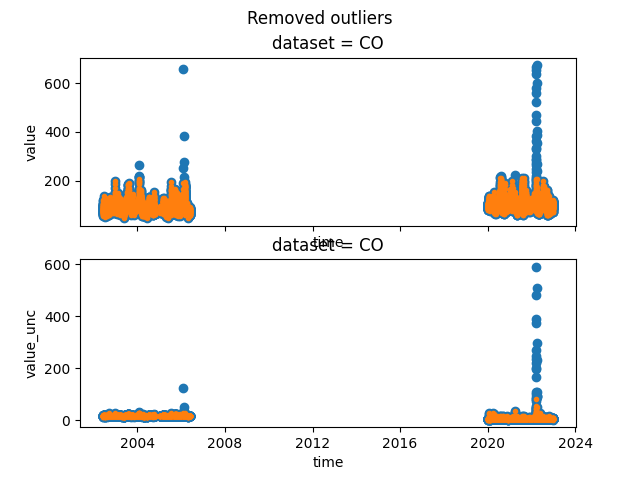

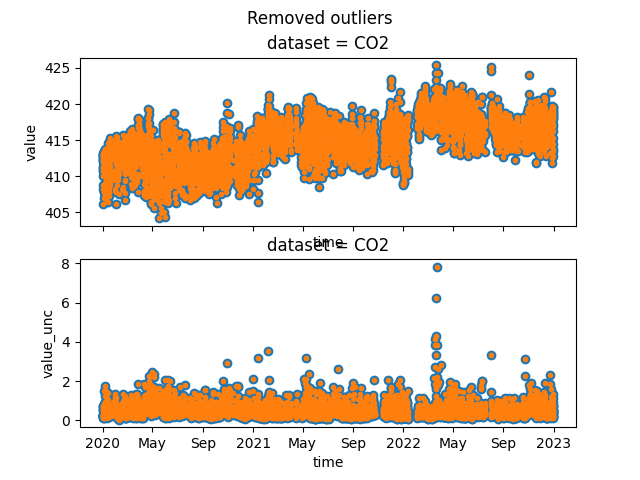

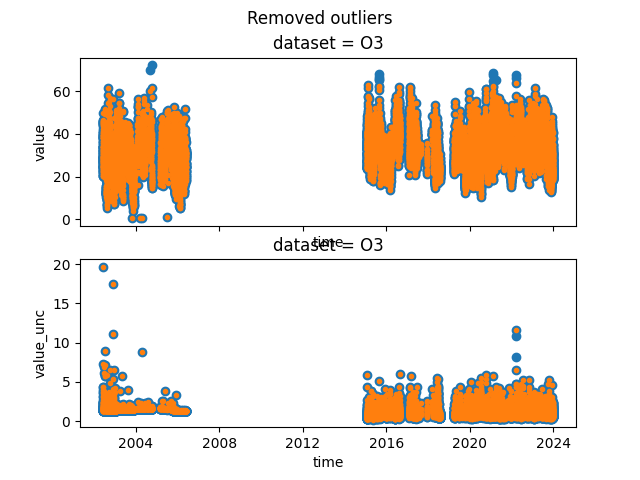

In [28]:
## Remove some outliers, especially wild fire CO

import process_data
ds_all_3h_rem_out = process_data.rem_out(ds_all_3h,std_fac=10, z_threshold=4)

## plot removed data
var = 'value'

for s in species_sel:

    f, axs = plt.subplots(2, 1, sharex=True)
    plt.suptitle("Removed outliers")
    ds_all_3h.sel(dataset=s)[var].plot(ls="", marker="o", ax=axs[0])
    ds_all_3h.sel(dataset=s)[var + "_unc"].plot(ls="", marker="o", ax=axs[1])
    # new data:
    ds_all_3h_rem_out.sel(dataset=s)[var].plot(ls="", marker=".", ax=axs[0])
    ds_all_3h_rem_out.sel(dataset=s)[var + "_unc"].plot(ls="", marker=".", ax=axs[1])
    plt.show()

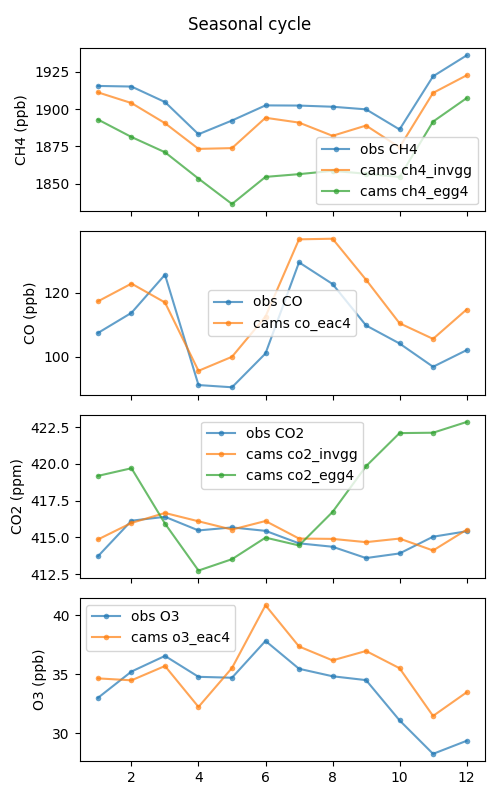

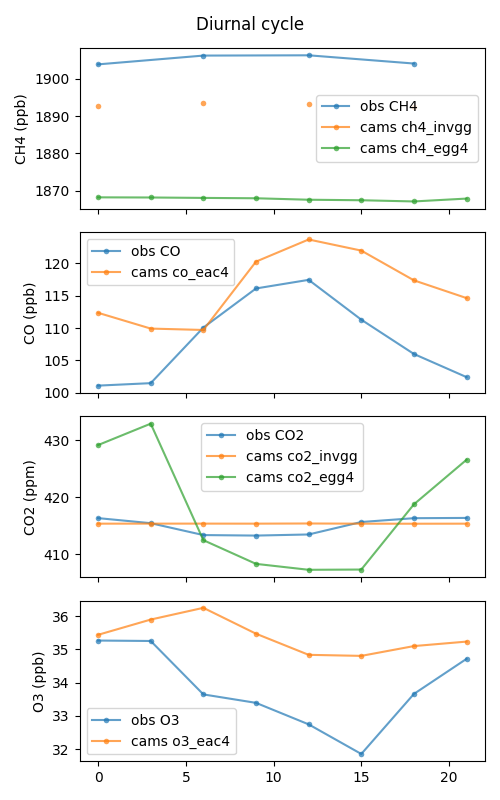

In [79]:
## plot  SEASONAL CYCLE and DIURNAL cams versus observations

alpha = 0.7
ms = 8

for freq in ['month','hour']:
    fig, axs = plt.subplots(
        len(species_sel), 1, sharex=True, figsize=(5, len(species_sel) * 2)
    )
    for s, ax in zip(species_sel, axs):
        if s == "CH4":
            ds = ds_all_6h  # ch4 has 6h resolution
        else:
            ds = ds_all_3h

        ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
        # select cams datasets that exist for this species
        cams_datasets_sel = [cams_sel for cams_sel in cams_best_grid.dataset.values if f"{s.lower()}_" in cams_sel]
        cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

        # function to plot each subplot
        def plot_data(ds,label):
            ds.groupby(f"time.{freq}").mean().plot(
                ax=ax,
                ls='-',
                marker='.',
                markeredgewidth=0,
                alpha=alpha,
                markersize=ms,
                label=f"{label} {str(ds.dataset.values)}",
            )

        # plot obs
        if len(ds_sel.dataset) > 1:  # several obs datasets with same species
            # plot only if we have data in our given time period:
            variables_to_keep = [
                    spec.dataset.values
                    for spec in ds_sel.dataset
                    if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
                ]
            for ds_i in ds_sel.sel(dataset=variables_to_keep).dataset:
                plot_data(ds_sel.sel(dataset=ds_i.values)["value"], 'obs')
        else:
            plot_data(ds_sel.sel(dataset=s)["value"], 'obs')

        # plot cams
        if len(cams.dataset) > 1:  # several cams datasets with same species
            # plot only if we have data in our given time period:
            variables_to_keep = [
                    spec.dataset.values
                    for spec in cams.dataset
                    if cams.sel(dataset=spec)["value"].isnull().all() == False
                ]
            for cams_i in cams.sel(dataset=variables_to_keep).dataset:
                plot_data(cams.sel(dataset=cams_i)["value"], 'cams')
        else:
            plot_data(cams.isel(dataset=0)["value"], 'cams')

        ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
        ax.set_xlabel("")
        ax.set_title("")
        ax.legend()
    
    if freq == 'month':
        tit = 'Seasonal'
    elif freq == 'hour':
        tit = 'Diurnal'

    plt.suptitle(f"{tit} cycle")
    plt.tight_layout()
    plt.show()

In [78]:
freq
[s if freq=='month' elif freq]

'hour'

In [17]:
ds_all.sel(dataset='CH4')

<xarray.Dataset>
Dimensions:             (time: 114106)
Coordinates:
  * time                (time) datetime64[ns] 2002-05-31T23:00:00 ... 2023-12...
    dataset             <U9 'CH4'
Data variables: (12/17)
    site_gaw_id         (time) object nan nan nan nan nan ... nan nan nan nan
    value               (time) float64 nan nan nan nan nan ... nan nan nan nan
    value_unc           (time) float64 nan nan nan nan nan ... nan nan nan nan
    nvalue              (time) float64 nan nan nan nan nan ... nan nan nan nan
    latitude            (time) float64 nan nan nan nan nan ... nan nan nan nan
    longitude           (time) float64 nan nan nan nan nan ... nan nan nan nan
    ...                  ...
    QCflag              (time) float64 nan nan nan nan nan ... nan nan nan nan
    instrument          (time) float64 nan nan nan nan nan ... nan nan nan nan
    measurement_method  (time) float64 nan nan nan nan nan ... nan nan nan nan
    scale               (time) float64 nan nan nan nan nan ... nan nan nan nan
    unit                <U3 'ppb'
    species             <U3 'CH4'

#### check ozone  data directly from file

In [18]:
import nappy
data_path = '../data/wdc/ebas/air/'
for file in os.listdir(data_path):
    if "ozone" in str(file):
       print(file)

file


KE0001G.20020601000000.20100322000000.uv_abs.ozone.air.7mo.1h.CH01L_uv_abs_MKN.CH01L_uv_abs..nas
KE0001G.20030101000000.20100322000000.uv_abs.ozone.air.1y.1h.CH01L_uv_abs_MKN.CH01L_uv_abs..nas
KE0001G.20040101000000.20100322000000.uv_abs.ozone.air.1y.1h.CH01L_uv_abs_MKN.CH01L_uv_abs..nas
KE0001G.20050101000000.20100322000000.uv_abs.ozone.air.1y.1h.CH01L_uv_abs_MKN.CH01L_uv_abs..nas
KE0001G.20060101000000.20100322000000.uv_abs.ozone.air.5mo.1h.CH01L_uv_abs_MKN.CH01L_uv_abs..nas
KE0001G.20150101000000.20201019094107.uv_abs.ozone.air.1y.1h.KE02L_TEI49C_no0330102716.KE02L_uv_abs.lev2.nas
KE0001G.20160101000000.20201019094107.uv_abs.ozone.air.1y.1h.KE02L_TEI49C_no0330102716.KE02L_uv_abs.lev2.nas
KE0001G.20170101000000.20201019094107.uv_abs.ozone.air.1y.1h.KE02L_TEI49C_no0330102716.KE02L_uv_abs.lev2.nas
KE0001G.20180101000000.20201019094107.uv_abs.ozone.air.1y.1h.KE02L_TEI49C_no0330102716.KE02L_uv_abs.lev2.nas
KE0001G.20190101000000.20201016090000.uv_abs.ozone.air.1y.1h.KE02L_TEI49C_no033010

'KE0001G.20230101000000.20240105090000.uv_abs.ozone.air.1y.1h.KE02L_TEI49C_no58106318.KE02L_uv_abs.lev2.nas'

In [19]:
%autoreload 2
from processing import ebas
df = ebas.compile_ebas_ozone_data_into_dataframe(data_path,read_unc=True)

In [20]:
pd.to_datetime(df.index[0])#.astype('DateTime64DType')
df.index[0]

Timestamp('2002-06-01 00:00:00')

In [21]:
df.to_xarray().O3.plot(marker='o',alpha=0.2,ls='')

In [22]:
## wdc data: 
from analyses_level2.read_data import AvailableData, create_data_reader

data_path = "../data/"
sel='CO2'
data_reader =  create_data_reader(data_path,sel) #creates an instance of the desired data_reader class
print(f"Data from {data_reader.__class__.__name__} for {sel}:")

# call the data-reading function on that instance: 
data = data_reader.read_data() 

Data from wdcGHGReader for CO2:
